# 🧠 From Text to Intelligent Dialogue: Exploring NLP with a Decision Map

**Notebook developed by** SzuLun Huang  
**Under the guidance of** Eric Van Dusen  
**UC Berkeley, Data Science**

---

### 📌 Compatibility
This notebook runs on **JupyterHub** (and other environments that have the model file).

> **Before you start:**
> - Click **Run All** once to load explanations and interactive widgets
> - The language model is loaded only in the marked cell; run Setup first

---


**Suggested core path:**  
Part 1 quiz → Part 2 NLP concepts → Part 3 modern pipeline → Part 4 decision map → Part 5 open case  

Bonus: SLM next-token, Attention game, RAG treasure hunt, same model for Sentiment / NER

**What you will do:**
1. Decide when rules are enough vs when stronger NLP / language models are needed
2. Build intuition for NLU and NLG
3. Learn the modern NLP path: Text → Tokenization → Embedding → Transformer → LLM → Task (and RAG when needed)
4. Use a decision map to choose a direction for a task
5. Watch a small language model predict the next token, then reuse it for sentiment and NER


In [1]:
#@title ⚙️ Notebook Setup — All libraries are imported once here
# Later cells do not re-import

import os
import sys
import re
import json
import math
import random
import subprocess

import numpy as np
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# llama-cpp may not be installed yet; confirm when loading the model
try:
    from llama_cpp import Llama
    _LLAMA_AVAILABLE = True
except ImportError:
    Llama = None
    _LLAMA_AVAILABLE = False

print('Setup complete.')
print(f'llama-cpp-python available: {_LLAMA_AVAILABLE}')
print('(The model is only loaded in the “Load language model” cell.)')


Setup complete.
llama-cpp-python available: True
(The model is only loaded in the “Load language model” cell.)


## 🗺️ First: Build the Thinking Path

This notebook is not about memorizing jargon. Build this path:

> **Problem / Data → Why a capability is needed → Which method family fits → What its limits are**

> 💬 **Zoey:** “So text means we should always use ChatGPT?”  
> **HAC:** “Not yet. ChatGPT is powerful, but not every text problem needs a large language model. We learn *why*, not slogans.”


## 🧭 Part 1: When Are Traditional Methods Not Enough?


Before modern NLP, test your intuition with realistic scenarios.  
For each question, decide: **Are rules / keywords / simple statistics enough, or do we need stronger NLP or a language model?**


In [2]:
#@title Part 1: Scenario quiz — rules enough, or stronger NLP?
quiz_bank = [
    {
        "question": "You filter spam whose subject always contains “You won a prize.” The rule barely changes. This task:",
        "options": ["A. Keywords / rules are usually enough", "B. A large language model is required"],
        "correct": 0,
        "explanation": "✅ Correct! When the format is fixed and keywords are stable, rules or simple classifiers are often faster, cheaper, and easier to debug."
    },
    {
        "question": "Customer reviews are full of sarcasm, e.g. “Awesome — waited three weeks for a broken package.” You need the real sentiment:",
        "options": ["A. Rules that count positive words are enough", "B. Usually needs stronger semantic understanding (modern NLP / LMs)"],
        "correct": 1,
        "explanation": "✅ Correct! Positive wording with negative meaning is a classic semantic hard case; keywords alone fail often."
    },
    {
        "question": "You translate French product manuals into English, with lots of context and technical terms:",
        "options": ["A. Word-by-word dictionary lookup is enough", "B. Machine translation / modern NLP is more common"],
        "correct": 1,
        "explanation": "✅ Correct! Translation needs context and fluency; modern sequence models beat pure dictionary lookup."
    },
    {
        "question": "An FAQ bot answers only 8 fixed questions (hours, address, returns…). Users mostly click buttons:",
        "options": ["A. A flow-based chatbot / rule flow is often a great fit", "B. Impossible without a GPT-level model"],
        "correct": 0,
        "explanation": "✅ Correct! Small scope and fixed answers favor flowchart + button navigation. Large models can help later, but are not the required starting point."
    },
    {
        "question": "Employees ask in many phrasings whether temporary remote work abroad is allowed. Answers must follow company policy docs:",
        "options": ["A. Let the model answer from memory", "B. Better to retrieve documents (RAG) then answer"],
        "correct": 1,
        "explanation": "✅ Correct! Policies change and answers should be traceable. Retrieve evidence first; don’t rely on memorized model knowledge alone."
    },
    {
        "question": "Extract dates, amounts, and party names from contracts:",
        "options": ["A. Information extraction / NER is a natural direction", "B. Only humans can do this"],
        "correct": 0,
        "explanation": "✅ Correct! This is classic information extraction; rules, traditional ML, or modern NER models can all apply depending on complexity."
    },
]

N_QUIZ = 4
quiz_questions = random.sample(quiz_bank, N_QUIZ)
current_q = 0
score = 0

question_label = widgets.HTML()
options_widget = widgets.RadioButtons(options=[], layout=widgets.Layout(width="720px"))
submit_btn = widgets.Button(description="Submit Answer", button_style="primary", disabled=True)
next_btn = widgets.Button(description="Next →", button_style="info", disabled=True)
feedback_area = widgets.HTML()
progress_label = widgets.HTML()

def on_option_change(change):
    submit_btn.disabled = (change["new"] is None)

options_widget.observe(on_option_change, names="value")

def show_question():
    global current_q
    q = quiz_questions[current_q]
    question_label.value = (
        f"<h3>Question {current_q+1} / {len(quiz_questions)}</h3>"
        f"<p style='color:#64748b; font-size:13px'>(Randomly sampled from a bank of {len(quiz_bank)} questions)</p>"
        f"<p style='font-size:15px'>{q['question']}</p>"
    )
    options_widget.options = q["options"]
    options_widget.value = None
    submit_btn.disabled = True
    feedback_area.value = ""
    next_btn.disabled = True
    progress_label.value = f"<p style='color:#334155; font-weight:600'>Score: {score} / {current_q}</p>"

def on_submit(b):
    global score, current_q
    if options_widget.value is None:
        feedback_area.value = "<p style='color:orange'>Please select an answer first.</p>"
        return
    selected_idx = options_widget.options.index(options_widget.value)
    q = quiz_questions[current_q]
    if selected_idx == q["correct"]:
        score += 1
        feedback_area.value = (
            f"<div style='color:#14532d; font-weight:bold; margin-top:8px; padding:12px; "
            f"background:#dcfce7; border-radius:8px; border:1px solid #86efac'>{q['explanation']}</div>"
        )
    else:
        feedback_area.value = (
            f"<div style='color:#7f1d1d; font-weight:bold; margin-top:8px; padding:12px; "
            f"background:#fee2e2; border-radius:8px; border:1px solid #fca5a5'>"
            f"❌ Not quite.<br><br>{q['explanation']}</div>"
        )
    submit_btn.disabled = True
    next_btn.disabled = False
    progress_label.value = f"<p style='color:#334155; font-weight:600'>Score: {score} / {current_q+1}</p>"

def on_next(b):
    global current_q
    current_q += 1
    if current_q < len(quiz_questions):
        show_question()
    else:
        question_label.value = f"<h3>🎉 Quiz complete!</h3><p style='font-size:16px'>Final score: <b>{score} / {len(quiz_questions)}</b></p>"
        options_widget.options = []
        feedback_area.value = """
        <div style='background:#1e3a5f; padding:16px; border-radius:10px; margin-top:12px; border-left:6px solid #60a5fa; color:#f1f5f9'>
        <b style='color:#93c5fd; font-size:16px'>Key takeaway:</b><br><br>
        <span style='color:#f8fafc'>Rules fit fixed, low-variation tasks;</span><br>
        <span style='color:#e2e8f0'>semantics, ambiguity, generation, and open dialogue more often need modern NLP / LMs;</span><br>
        <span style='color:#e2e8f0'>when you need up-to-date or internal knowledge, think retrieval and evidence (RAG), not model memory alone.</span>
        </div>
        """
        submit_btn.disabled = True
        next_btn.disabled = True
        progress_label.value = ""

submit_btn.on_click(on_submit)
next_btn.on_click(on_next)
show_question()
display(progress_label, question_label, options_widget, widgets.HBox([submit_btn, next_btn]), feedback_area)


HTML(value="<p style='color:#334155; font-weight:600'>Score: 0 / 0</p>")

HTML(value="<h3>Question 1 / 4</h3><p style='color:#64748b; font-size:13px'>(Randomly sampled from a bank of 6…

RadioButtons(layout=Layout(width='720px'), options=('A. Let the model answer from memory', 'B. Better to retri…

HTML(value='')

> 💬 **Zoey:** “So sometimes rules are enough, and sometimes we really need a smarter model?”  
> **HAC:** “Yes. Look at **how much the problem varies** and **how deep the understanding must be**, then choose the complexity.”


## 🧩 Part 2: What Is NLP Doing?

Natural Language Processing is the field of techniques that let computers process, understand, and generate human language.

A useful teaching split (modern systems often cross both):

| Direction | Full name | Intuition |
|-----------|-----------|-----------|
| **NLU** | Natural Language Understanding | Read: classify, extract, intent, sentiment |
| **NLG** | Natural Language Generation | Write: summarize, translate, reply, create |

> Don’t memorize definitions. Ask: is this task more about understanding, generation, or both?


### 📚 Structured Data vs. Natural Language

Computers traditionally shine on clean structured data — ages, amounts, dates, categories in tables.

But much human information is not a tidy table:
- Email, chat, reviews
- Contracts and policy documents
- Speech transcribed into text

NLP works on language that is **messy, ambiguous, and context-dependent**.


## 🧠 Modern NLP Mental Map


We know NLP covers understanding and generation.  
Before memorizing model names, lock in this modern path:

> **Text → Tokenization → Embedding → Transformer → LLM → Task**  
> If you need external / up-to-date knowledge, add **Retrieval → RAG**


<div style="text-align:center; margin: 12px 0 28px 0;">
  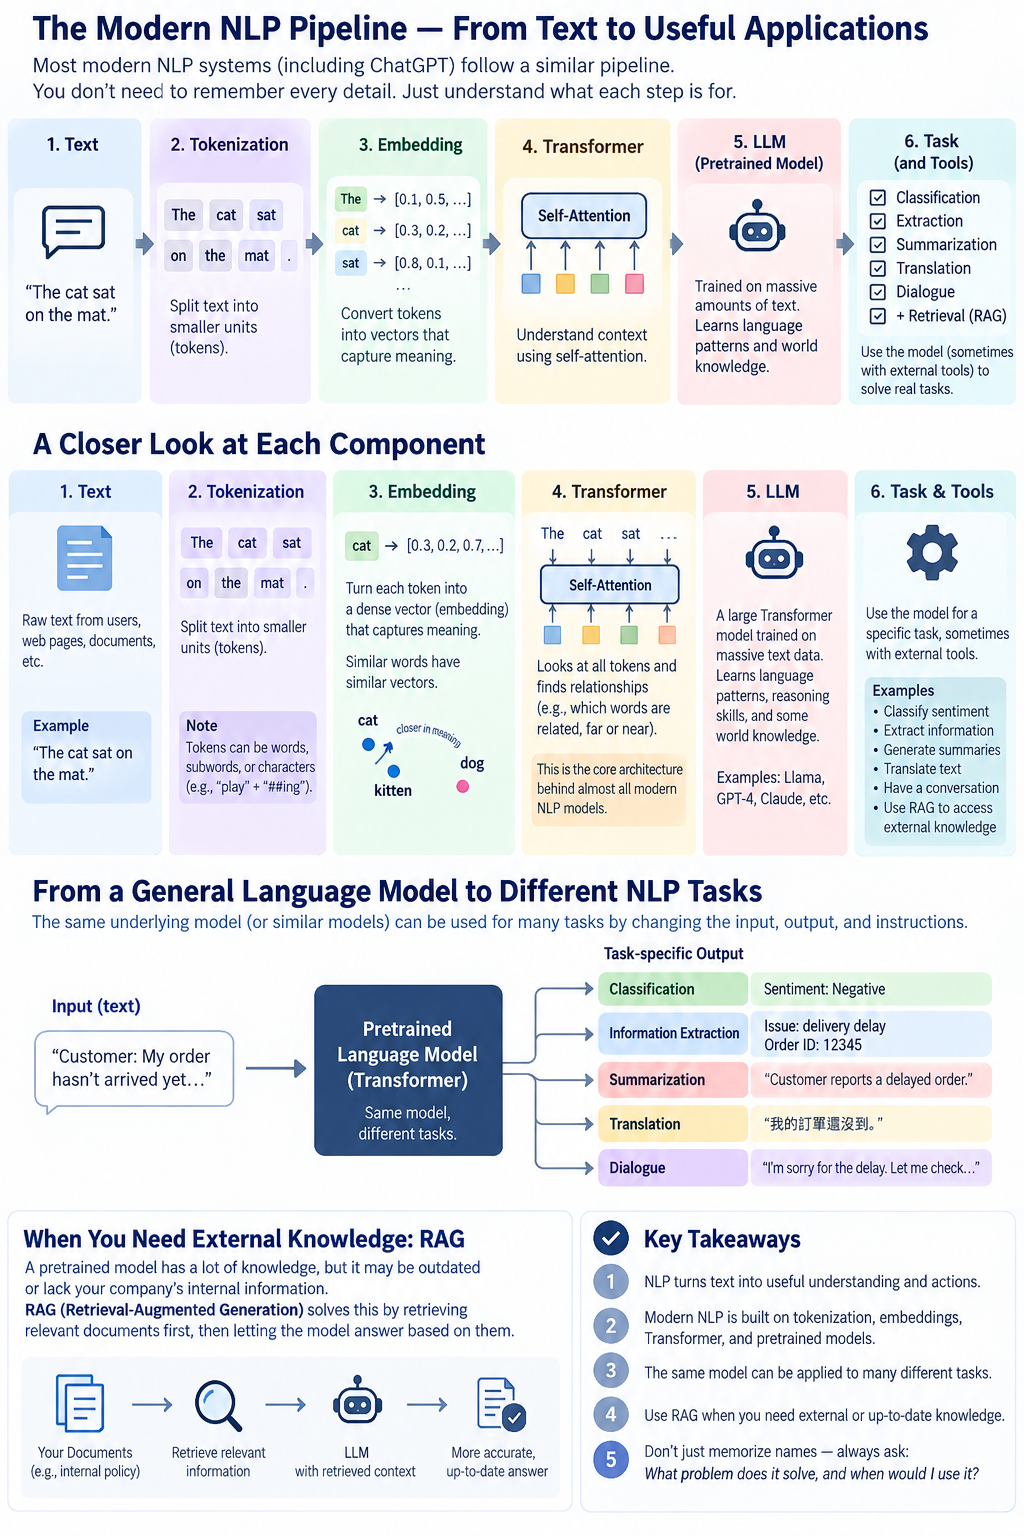
</div>


## 🔬 Part 3: Meet a Real Small Language Model (SLM)

So far we stayed conceptual. Here we load a **Small Language Model** so you can see:

1. How it “guesses the next token” for a sentence  
2. How the same model can do sentiment or NER when you change the prompt  

> This is not about training a model. It is about intuition:  
> **A core behavior of modern LLMs / SLMs is predicting the next token under context.**


In [3]:
#@title Load language model（load once here only）
# Depends on Setup: os / sys / subprocess / Llama

def detect_env():
    try:
        import google.colab  # optional
        return 'colab'
    except ImportError:
        pass
    if os.environ.get('JUPYTERHUB_USER') or os.environ.get('JPY_SESSION_NAME'):
        return 'jupyterhub'
    return 'local'

ENV = detect_env()
print(f'Environment detected: {ENV}')

global Llama, _LLAMA_AVAILABLE, llm
if not _LLAMA_AVAILABLE or Llama is None:
    print('Installing llama-cpp-python（prebuilt wheel）...')
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', 'llama-cpp-python',
        '--extra-index-url', 'https://abetlen.github.io/llama-cpp-python/whl/cpu',
        '--quiet'
    ], check=False)
    from llama_cpp import Llama as _Llama
    Llama = _Llama
    _LLAMA_AVAILABLE = True
    print('Install complete。')

if ENV == 'colab':
    MODEL_PATH = '/content/models/Llama-3.2-1B-Instruct-Q4_K_M.gguf'
elif ENV == 'jupyterhub':
    MODEL_PATH = '/home/jovyan/shared/Llama-3.2-1B-Instruct-Q4_K_M.gguf'
else:
    MODEL_PATH = 'Llama-3.2-1B-Instruct-Q4_K_M.gguf'

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f'Model file not found：{MODEL_PATH}\n'
        f'Check that the shared folder has this file, or ask the TA whether the model was uploaded.'
    )

llm = Llama(model_path=MODEL_PATH, n_ctx=1024, verbose=False, logits_all=True)
print('Model loaded. You can start.')


Environment detected: jupyterhub
Model loaded. You can start.


### 🎯 How to play: guess first, then see the model

1. Type the start of a sentence (prefer **English**; Chinese may show odd subword splits — a real limit, not a bug)  
2. **Guess** what the model thinks comes next  
3. Run and compare with the probability distribution  


### 🎰 After next-token probabilities — then what?


A language model produces a **next-token probability distribution** at each step.

That single mechanism supports many tasks once you change the prompt and decoding setup.


In [4]:
#@title 🎰 Guess the Next Token + Language Model Probability Chain

# ============================================================
# EXAMPLE PROMPTS
# ============================================================

example_sentences = [
    "The capital of France is",
    "Peanut butter and",
    "The student opened the",
    "Artificial intelligence will",
    "I went to the bank to",
]


# ============================================================
# GAME STATE
# ============================================================

lm_state = {
    "text": "The student opened the",
    "step": 0,
    "history": []
}


# ============================================================
# WIDGETS
# ============================================================

sentence_box = widgets.Text(
    value=lm_state["text"],
    description="Prompt:",
    style={"description_width": "85px"},
    layout=widgets.Layout(width="620px")
)

guess_box = widgets.Text(
    placeholder="Your guess for the next token (optional)",
    description="Your guess:",
    style={"description_width": "85px"},
    layout=widgets.Layout(width="500px")
)

reveal_btn = widgets.Button(
    description="🔍 Reveal Next Token",
    button_style="primary",
    layout=widgets.Layout(width="200px")
)

reset_btn = widgets.Button(
    description="↺ Reset",
    layout=widgets.Layout(width="100px")
)

mode_choice = widgets.ToggleButtons(
    options=[
        ("👤 Human", "human"),
        ("🥇 Greedy", "greedy"),
        ("🎲 Sampling", "sampling"),
    ],
    value="human",
    description="Mode:",
    style={"description_width": "55px"},
)

temperature_slider = widgets.FloatSlider(
    value=0.8,
    min=0.2,
    max=1.5,
    step=0.1,
    description="Temperature:",
    style={"description_width": "90px"},
    layout=widgets.Layout(width="380px")
)

generate_steps = widgets.IntSlider(
    value=6,
    min=1,
    max=12,
    step=1,
    description="Steps:",
    style={"description_width": "55px"},
    layout=widgets.Layout(width="300px")
)

auto_generate_btn = widgets.Button(
    description="▶ Auto Generate",
    button_style="success",
    layout=widgets.Layout(width="160px")
)

game_output = widgets.Output()
history_output = widgets.Output()


# ============================================================
# MODEL HELPERS
# ============================================================

def get_top_tokens(prompt, top_k=5, temperature=1.0):
    result = llm.create_completion(
        prompt,
        max_tokens=1,
        logprobs=top_k,
        echo=False,
        temperature=temperature
    )

    top_logprobs = (
        result["choices"][0]
        ["logprobs"]
        ["top_logprobs"][0]
    )

    tokens = [
        (tok, math.exp(lp))
        for tok, lp in top_logprobs.items()
    ]

    tokens.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return tokens


def normalize_probs(tokens):
    total = sum(prob for _, prob in tokens)

    if total == 0:
        return tokens

    return [
        (tok, prob / total)
        for tok, prob in tokens
    ]


def sample_token(tokens):
    tokens = normalize_probs(tokens)

    r = random.random()
    cumulative = 0

    for tok, prob in tokens:
        cumulative += prob

        if r <= cumulative:
            return tok, prob

    return tokens[-1]


def visible_token(tok):
    return (
        tok
        .replace(" ", "␠")
        .replace("\n", "↵")
        .replace("\t", "⇥")
    )


# ============================================================
# RENDER TOKEN DISTRIBUTION
# ============================================================

def render_bars(tokens, user_guess=""):
    max_prob = max(prob for _, prob in tokens)

    rows = ""

    for rank, (tok, prob) in enumerate(tokens, start=1):
        pct = prob * 100
        bar_width = (
            prob / max_prob * 100
            if max_prob > 0
            else 0
        )

        display_tok = visible_token(tok)

        guess_match = (
            user_guess.strip()
            and user_guess.strip().lower()
            == tok.strip().lower()
        )

        border = (
            "2px solid #f59e0b"
            if guess_match
            else "1px solid #334155"
        )

        badge = (
            " ← YOUR GUESS"
            if guess_match
            else ""
        )

        rows += f"""
        <div style="
            margin:6px 0;
            padding:8px 10px;
            border:{border};
            border-radius:8px;
            background:#111827;
        ">
          <div style="display:flex;align-items:center;gap:10px;">

            <div style="
                width:26px;
                color:#94a3b8;
                font-size:13px;
            ">
                #{rank}
            </div>

            <div style="
                min-width:120px;
                font-family:monospace;
                font-size:15px;
                font-weight:700;
                color:#f8fafc;
            ">
                {display_tok}
                <span style="font-size:10px;color:#fbbf24;">
                    {badge}
                </span>
            </div>

            <div style="
                flex:1;
                height:14px;
                background:#1e293b;
                border-radius:7px;
                overflow:hidden;
            ">
              <div style="
                  width:{bar_width:.1f}%;
                  height:100%;
                  background:#38bdf8;
              "></div>
            </div>

            <div style="
                min-width:55px;
                text-align:right;
                font-size:13px;
                color:#cbd5e1;
            ">
                {pct:.1f}%
            </div>

          </div>
        </div>
        """

    return rows


# ============================================================
# HISTORY DISPLAY
# ============================================================

def render_history():
    with history_output:
        clear_output()

        if not lm_state["history"]:
            return

        rows = ""

        for i, item in enumerate(lm_state["history"], start=1):
            token = visible_token(item["token"])
            prob = item["prob"] * 100

            rows += f"""
            <tr>
                <td style="padding:5px 10px;">{i}</td>
                <td style="padding:5px 10px;font-family:monospace;">{token}</td>
                <td style="padding:5px 10px;">{prob:.1f}%</td>
                <td style="padding:5px 10px;">{item['mode']}</td>
            </tr>
            """

        display(
            HTML(f"""
            <div style="
                max-width:640px;
                margin-top:14px;
                padding:12px 14px;
                border:1px solid #cbd5e1;
                border-radius:10px;
                background:#f8fafc;
            ">

                <div style="
                    font-size:15px;
                    font-weight:800;
                    margin-bottom:8px;
                ">
                    🔗 Probability Chain History
                </div>

                <table style="
                    border-collapse:collapse;
                    width:100%;
                    font-size:14px;
                ">
                    <tr style="text-align:left;color:#475569;">
                        <th style="padding:5px 10px;">Step</th>
                        <th style="padding:5px 10px;">Token</th>
                        <th style="padding:5px 10px;">Probability</th>
                        <th style="padding:5px 10px;">Mode</th>
                    </tr>
                    {rows}
                </table>

            </div>
            """)
        )


# ============================================================
# ADD TOKEN
# ============================================================

def append_token(tok, prob, mode):
    lm_state["text"] += tok
    lm_state["step"] += 1

    lm_state["history"].append({
        "token": tok,
        "prob": prob,
        "mode": mode
    })

    sentence_box.value = lm_state["text"]

    render_history()


# ============================================================
# HUMAN REVEAL
# ============================================================

def reveal_next(_):
    with game_output:
        clear_output()

        prompt = sentence_box.value

        if not prompt.strip():
            print("⚠️ Please enter a sentence first.")
            return

        lm_state["text"] = prompt

        tokens = get_top_tokens(
            prompt,
            top_k=5,
            temperature=1.0
        )

        guess = guess_box.value

        display(
            HTML(f"""
            <div style="
                background:#0d1420;
                border:1px solid #38bdf8;
                border-radius:12px;
                padding:16px 18px;
                color:#e2e8f0;
                max-width:640px;
            ">

                <div style="
                    font-size:11px;
                    font-weight:800;
                    color:#38bdf8;
                    margin-bottom:5px;
                ">
                    ROUND {lm_state["step"] + 1} — CURRENT CONTEXT
                </div>

                <div style="
                    font-size:18px;
                    font-family:monospace;
                    margin-bottom:15px;
                ">
                    “{prompt}”
                </div>

                <div style="
                    font-size:11px;
                    font-weight:800;
                    color:#fbbf24;
                    margin-bottom:7px;
                ">
                    MODEL'S TOP-5 NEXT TOKENS
                </div>

                {render_bars(tokens, guess)}

            </div>
            """)
        )

        if guess.strip():
            matched = any(
                guess.strip().lower()
                == tok.strip().lower()
                for tok, _ in tokens
            )

            if matched:
                print("🎯 Your guess is in the Top-5!")
            else:
                print("🤔 Your guess is not in the Top-5.")

        if mode_choice.value != "human":
            display(
                HTML("""
                <div style="
                    margin-top:10px;
                    color:#64748b;
                    font-size:14px;
                ">
                    Not in Human mode. You can also use Auto Generate。
                </div>
                """)
            )
            return

        buttons = []

        for tok, prob in tokens:
            btn = widgets.Button(
                description=f"{visible_token(tok)}  ({prob*100:.1f}%)",
                layout=widgets.Layout(
                    width="145px",
                    height="40px"
                )
            )

            def make_handler(chosen_tok, chosen_prob):
                def handler(_):
                    append_token(
                        chosen_tok,
                        chosen_prob,
                        "Human"
                    )

                    guess_box.value = ""

                    with game_output:
                        clear_output()

                    reveal_next(None)

                return handler

            btn.on_click(
                make_handler(tok, prob)
            )

            buttons.append(btn)

        display(
            HTML("""
            <div style="
                margin-top:12px;
                margin-bottom:5px;
                font-weight:700;
            ">
                👤 Human Mode: pick the next token
            </div>
            """)
        )

        display(
            widgets.HBox(
                buttons,
                layout=widgets.Layout(
                    flex_flow="row wrap"
                )
            )
        )


# ============================================================
# AUTO GENERATION
# ============================================================

def auto_generate(_):
    with game_output:
        clear_output()

        lm_state["text"] = sentence_box.value

        steps = generate_steps.value
        mode = mode_choice.value
        temperature = temperature_slider.value

        if mode == "human":
            display(
                HTML("""
                <div style="
                    padding:10px;
                    color:#92400e;
                    background:#fffbeb;
                    border:1px solid #fde68a;
                    border-radius:8px;
                    max-width:620px;
                ">
                    👤 Human mode: press Reveal, then pick a token yourself.
                </div>
                """)
            )
            return

        chain_rows = ""

        for step in range(steps):
            prompt = lm_state["text"]

            tokens = get_top_tokens(
                prompt,
                top_k=5,
                temperature=temperature
            )

            if mode == "greedy":
                chosen_tok, chosen_prob = tokens[0]
                mode_label = "Greedy"

            else:
                chosen_tok, chosen_prob = sample_token(tokens)
                mode_label = f"Sampling T={temperature:.1f}"

            append_token(
                chosen_tok,
                chosen_prob,
                mode_label
            )

            top3_text = " | ".join(
                f"{visible_token(tok)} {prob*100:.1f}%"
                for tok, prob in tokens[:3]
            )

            chain_rows += f"""
            <div style="
                margin:7px 0;
                padding:10px 12px;
                border:1px solid #334155;
                border-radius:8px;
                background:#111827;
            ">

                <div style="
                    font-size:12px;
                    color:#94a3b8;
                ">
                    STEP {lm_state["step"]}
                </div>

                <div style="
                    margin:4px 0;
                    font-size:16px;
                    color:#f8fafc;
                ">
                    Chosen:
                    <b style="color:#38bdf8;">
                        {visible_token(chosen_tok)}
                    </b>
                    &nbsp;
                    ({chosen_prob*100:.1f}%)
                </div>

                <div style="
                    font-size:12px;
                    color:#cbd5e1;
                ">
                    Top candidates: {top3_text}
                </div>

            </div>
            """

        display(
            HTML(f"""
            <div style="
                max-width:640px;
                background:#0d1420;
                border:1px solid #38bdf8;
                border-radius:12px;
                padding:16px;
                color:#e2e8f0;
            ">

                <div style="
                    font-size:13px;
                    font-weight:800;
                    color:#fbbf24;
                    margin-bottom:8px;
                ">
                    🎰 LANGUAGE MODEL PROBABILITY CHAIN
                </div>

                {chain_rows}

                <hr style="
                    border:none;
                    border-top:1px solid #334155;
                    margin:14px 0;
                ">

                <div style="
                    font-size:13px;
                    color:#94a3b8;
                    margin-bottom:5px;
                ">
                    GENERATED TEXT
                </div>

                <div style="
                    font-family:monospace;
                    font-size:18px;
                    line-height:1.55;
                    color:#f8fafc;
                ">
                    {lm_state["text"]}
                </div>

            </div>
            """)
        )


# ============================================================
# EXAMPLE BUTTONS
# ============================================================

example_buttons = []

for text in example_sentences:
    btn = widgets.Button(
        description=text,
        layout=widgets.Layout(
            width="245px",
            height="38px",
            margin="3px"
        )
    )

    def make_example_handler(example_text):
        def handler(_):
            lm_state["text"] = example_text
            lm_state["step"] = 0
            lm_state["history"] = []

            sentence_box.value = example_text
            guess_box.value = ""

            with game_output:
                clear_output()

            with history_output:
                clear_output()

        return handler

    btn.on_click(
        make_example_handler(text)
    )

    example_buttons.append(btn)


# ============================================================
# RESET
# ============================================================

def reset_game(_):
    default_text = "The student opened the"

    lm_state["text"] = default_text
    lm_state["step"] = 0
    lm_state["history"] = []

    sentence_box.value = default_text
    guess_box.value = ""

    with game_output:
        clear_output()

    with history_output:
        clear_output()


reset_btn.on_click(reset_game)
reveal_btn.on_click(reveal_next)
auto_generate_btn.on_click(auto_generate)


# ============================================================
# SYNC MANUAL TEXT EDITING
# ============================================================

def sync_sentence(change):
    if change["name"] == "value":
        lm_state["text"] = change["new"]


sentence_box.observe(
    sync_sentence,
    names="value"
)


# ============================================================
# DISPLAY
# ============================================================

display(
    HTML("""
    <h3 style="
        font-size:23px;
        color:#1e3a8a;
        margin-bottom:4px;
    ">
        🎰 Language Model Probability Chain
    </h3>

    <p style="
        max-width:650px;
        color:#475569;
        font-size:15px;
        line-height:1.55;
    ">
        At each step, the language model uses
        <b>the full current context</b>
        to recompute the next-token probability distribution。
        <br><br>
        It does not plan the whole sentence first, then emit it once.
        Instead:
        <b>predict → choose → append → predict again</b>。
    </p>
    """)
)

display(
    HTML("<b>🎯 Try an example:</b>")
)

display(
    widgets.VBox([
        widgets.HBox(example_buttons[:2]),
        widgets.HBox(example_buttons[2:4]),
        widgets.HBox(example_buttons[4:])
    ])
)

display(HTML("<div style='height:10px'></div>"))

display(sentence_box)
display(guess_box)

display(
    widgets.HBox([
        reveal_btn,
        reset_btn
    ])
)

display(
    HTML("""
    <hr style="
        max-width:640px;
        margin:18px 0 12px;
    ">

    <div style="
        font-size:16px;
        font-weight:800;
        margin-bottom:8px;
    ">
        🔗 Probability Chain Mode
    </div>
    """)
)

display(mode_choice)

display(
    widgets.HBox([
        temperature_slider,
        generate_steps
    ])
)

display(auto_generate_btn)

display(game_output)
display(history_output)


Text(value='The student opened the', description='Prompt:', layout=Layout(width='620px'), style=TextStyle(desc…

Text(value='', description='Your guess:', layout=Layout(width='500px'), placeholder='Your guess for the next t…

ToggleButtons(description='Mode:', options=(('👤 Human', 'human'), ('🥇 Greedy', 'greedy'), ('🎲 Sampling', 'samp…

Button(button_style='success', description='▶ Auto Generate', layout=Layout(width='160px'), style=ButtonStyle(…

Output()

Output()

### 🔦 Game: Attention Spotlight — Context Detective

One core Transformer idea: **a word’s meaning depends on which other words it relates to in context.**

This game avoids formulas. Practice: to understand the highlighted word, which words would you attend to?


In [5]:
#@title 🔦 Game: Attention Spotlight

attention_rounds = [
    {
        "sentence": "The animal didn't cross the street because it was too tired.",
        "focus": "it",
        "question": "What does “it” most likely refer to?",
        "choices": ["animal", "street", "cross"],
        "answer": "animal",
        "why": "too tired fits the animal better, so context links “it” strongly to the animal.",
        "weights": {"animal": 0.82, "street": 0.12, "cross": 0.06},
    },
    {
        "sentence": "The animal didn't cross the street because it was too wide.",
        "focus": "it",
        "question": "What does “it” most likely refer to this time?",
        "choices": ["animal", "street", "cross"],
        "answer": "street",
        "why": "too wide fits the street better. Changing one context word changes the referent.",
        "weights": {"animal": 0.10, "street": 0.84, "cross": 0.06},
    },
    {
        "sentence": "Alex thanked Jordan because they helped finish the report.",
        "focus": "they",
        "question": "In this sentence alone, who does “they” most likely link to?",
        "choices": ["Alex", "Jordan", "report"],
        "answer": "Jordan",
        "why": " Jordan is the person being thanked; “helped finish the report” is the natural reason.",
        "weights": {"Alex": 0.25, "Jordan": 0.68, "report": 0.07},
    },
    {
        "sentence": "The chef put the cake in the fridge because it needed to stay cold.",
        "focus": "it",
        "question": "What does “it” most likely refer to?",
        "choices": ["chef", "cake", "fridge"],
        "answer": "cake",
        "why": "needed to stay cold is why the cake was put in the fridge.",
        "weights": {"chef": 0.05, "cake": 0.88, "fridge": 0.07},
    },
]

att_i = 0
att_score = 0
att_streak = 0
att_answered = False

att_header = widgets.HTML()
att_question = widgets.HTML()
att_choices = widgets.ToggleButtons(style={"button_width": "120px"})
att_submit = widgets.Button(description="🔦 Lock Answer", button_style="primary")
att_next = widgets.Button(description="➡️ Next Case", disabled=True)
att_feedback = widgets.HTML()


def _attention_bars(weights):
    rows = []
    for word, value in weights.items():
        pct = int(round(value * 100))
        rows.append(f"""
        <div style='display:grid;grid-template-columns:85px 1fr 48px;gap:8px;align-items:center;margin:7px 0;'>
          <div style='font-weight:700;'>{word}</div>
          <div style='height:16px;background:#e5e7eb;border-radius:999px;overflow:hidden;'>
            <div style='width:{pct}%;height:100%;background:#6366f1;border-radius:999px;'></div>
          </div>
          <div style='font-size:13px;color:#475569;'>{pct}%</div>
        </div>
        """)
    return "".join(rows)


def show_attention_round():
    global att_answered
    att_answered = False
    q = attention_rounds[att_i]

    att_header.value = f"""
    <div style='font-size:15px;font-weight:700;margin:4px 0 10px 0;'>
      🧠 Score: {att_score} &nbsp;&nbsp; 🔥 Streak: {att_streak} &nbsp;&nbsp; Case {att_i+1}/{len(attention_rounds)}
    </div>
    """

    highlighted = q["sentence"].replace(
        q["focus"],
        f"<span style='background:#fef3c7;padding:2px 6px;border-radius:6px;font-weight:800;'>{q['focus']}</span>",
        1
    )

    att_question.value = f"""
    <div style='max-width:620px;padding:16px 18px;border:2px solid #c7d2fe;border-radius:14px;background:#ffffff;'>
      <div style='font-size:13px;font-weight:800;color:#6366f1;margin-bottom:6px;'>CONTEXT CASE #{att_i+1}</div>
      <div style='font-size:21px;line-height:1.5;font-weight:700;color:#1f2937;'>{highlighted}</div>
      <div style='font-size:16px;margin-top:12px;color:#374151;'>🎯 {q['question']}</div>
    </div>
    """

    att_choices.options = q["choices"]
    att_choices.value = q["choices"][0]
    att_feedback.value = ""
    att_submit.disabled = False
    att_next.disabled = True


def check_attention(_):
    global att_score, att_streak, att_answered
    if att_answered:
        return
    att_answered = True
    q = attention_rounds[att_i]
    selected = att_choices.value
    correct = selected == q["answer"]

    if correct:
        att_score += 1
        att_streak += 1
        title = "✅ Nice! Context locked."
        bg = "#ecfdf5"
        border = "#86efac"
    else:
        att_streak = 0
        title = f"🧐 Better answer: {q['answer']}"
        bg = "#fff7ed"
        border = "#fdba74"

    att_feedback.value = f"""
    <div style='max-width:620px;margin-top:12px;padding:14px 16px;border:2px solid {border};border-radius:12px;background:{bg};'>
      <div style='font-size:19px;font-weight:800;margin-bottom:6px;'>{title}</div>
      <div style='font-size:15px;line-height:1.5;margin-bottom:12px;'>{q['why']}</div>
      <div style='font-size:14px;font-weight:800;color:#4338ca;margin-bottom:4px;'>TOY ATTENTION SPOTLIGHT</div>
      {_attention_bars(q['weights'])}
      <div style='font-size:12px;color:#64748b;margin-top:9px;'>⚠️ This is a teaching visualization, not real attention weights from a model.</div>
    </div>
    """

    att_header.value = f"""
    <div style='font-size:15px;font-weight:700;margin:4px 0 10px 0;'>
      🧠 Score: {att_score} &nbsp;&nbsp; 🔥 Streak: {att_streak} &nbsp;&nbsp; Case {att_i+1}/{len(attention_rounds)}
    </div>
    """
    att_submit.disabled = True
    att_next.disabled = False


def next_attention(_):
    global att_i
    att_i = (att_i + 1) % len(attention_rounds)
    show_attention_round()

att_submit.on_click(check_attention)
att_next.on_click(next_attention)

display(HTML("""
<h3 style='font-size:22px;color:#1e3a8a;margin-bottom:4px;'>🔦 Attention Spotlight</h3>
<p style='max-width:620px;font-size:15px;color:#475569;'>The same pronoun can shift its main links when context changes.</p>
"""))
display(att_header, att_question, att_choices, widgets.HBox([att_submit, att_next]), att_feedback)
show_attention_round()


HTML(value='')

HTML(value='')

ToggleButtons(options=(), style=ToggleButtonsStyle(button_width='120px'), value=None)

HTML(value='')

### 📚 Game: RAG Treasure Hunt — Find evidence before answering

Don’t let the model guess blindly. You play the **Retriever**:

1. Read the question  
2. Pick the document most worth searching  
3. Lock the supporting evidence  
4. Only then form the answer  

Teaching version of RAG: **Retrieval → Augmented → Generation**.


In [6]:
#@title 📚 RAG Treasure Hunt
# Staged UI so document choice and evidence do not overlap

rag_cases = [
    {
        "question": "How many paid vacation days do employees get per year?",
        "doc": "🏖️ Vacation Policy",
        "docs": [
            "🏖️ Vacation Policy",
            "💳 Expense Policy",
            "🔐 Security Policy",
            "🏠 Remote Work",
            "🩺 Benefits",
            "🚗 Parking Rules",
        ],
        "snippets": [
            "Full-time employees receive 15 paid vacation days per calendar year.",
            "Vacation requests should normally be submitted at least 5 business days in advance.",
            "Unused vacation may be subject to carry-over limits.",
        ],
        "evidence": "Full-time employees receive 15 paid vacation days per calendar year.",
        "answer": "Full-time employees receive 15 paid vacation days per calendar year.",
    },
    {
        "question": "What is the dinner reimbursement cap?",
        "doc": "💳 Expense Policy",
        "docs": [
            "🏖️ Vacation Policy",
            "💳 Expense Policy",
            "🔐 Security Policy",
            "🏠 Remote Work",
            "🩺 Benefits",
            "🚗 Parking Rules",
        ],
        "snippets": [
            "Business meals require an itemized receipt.",
            "Dinner reimbursement is capped at $45 per person unless pre-approved.",
            "Alcohol is not reimbursable under the standard meal policy.",
        ],
        "evidence": "Dinner reimbursement is capped at $45 per person unless pre-approved.",
        "answer": "Dinner reimbursement is capped at $45 per person unless pre-approved.",
    },
    {
        "question": "Can employees do temporary remote work from abroad?",
        "doc": "🏠 Remote Work",
        "docs": [
            "🏖️ Vacation Policy",
            "💳 Expense Policy",
            "🔐 Security Policy",
            "🏠 Remote Work",
            "🩺 Benefits",
            "🚗 Parking Rules",
        ],
        "snippets": [
            "Temporary remote work outside the employee's home country requires manager and HR approval.",
            "Employees are responsible for maintaining a reliable internet connection.",
            "Remote work arrangements may be reviewed when business needs change.",
        ],
        "evidence": "Temporary remote work outside the employee's home country requires manager and HR approval.",
        "answer": "Yes, but temporary work outside the home country requires manager and HR approval.",
    },
]

rag_i = 0
rag_score = 0

rag_header = widgets.HTML()
rag_question_box = widgets.HTML()
rag_feedback = widgets.HTML()

# Step 1 UI
rag_doc_choice = widgets.ToggleButtons(
    options=[],
    style={"button_width": "150px"},
    layout=widgets.Layout(width="100%", margin="4px 0")
)
rag_doc_button = widgets.Button(
    description="🔍 Search Document",
    button_style="primary",
    layout=widgets.Layout(width="180px")
)
rag_step1 = widgets.VBox([
    widgets.HTML("<div style='font-size:13px;font-weight:700;color:#92400e;margin:8px 0 4px;'>Step 1 · Choose a document</div>"),
    rag_doc_choice,
    rag_doc_button,
])

# Step 2 UI (hidden until document is correct)
rag_evidence_choice = widgets.RadioButtons(
    options=[],
    layout=widgets.Layout(width="100%")
)
rag_evidence_button = widgets.Button(
    description="🧾 Lock Evidence",
    button_style="success",
    layout=widgets.Layout(width="160px")
)
rag_next_button = widgets.Button(
    description="➡️ Next Hunt",
    button_style="info",
    layout=widgets.Layout(width="140px"),
    disabled=True
)
rag_step2 = widgets.VBox([
    widgets.HTML("<div style='font-size:13px;font-weight:700;color:#065f46;margin:12px 0 4px;'>Step 2 · Pick evidence</div>"),
    rag_evidence_choice,
    widgets.HBox([rag_evidence_button, rag_next_button], layout=widgets.Layout(margin="6px 0")),
])
rag_step2.layout.display = "none"

def update_rag_header():
    rag_header.value = f"""
    <div style='max-width:680px;display:flex;justify-content:space-between;align-items:center;
                margin:4px 0 12px;font-family:Arial,sans-serif;'>
      <div style='font-size:20px;font-weight:800;color:#92400e;'>📚 RAG Treasure Hunt</div>
      <div style='font-size:14px;font-weight:700;color:#475569;'>
        💰 Score: {rag_score} &nbsp;·&nbsp; Hunt {rag_i+1}/{len(rag_cases)}
      </div>
    </div>
    <p style='max-width:680px;font-size:14px;color:#475569;margin:0 0 8px;'>
      You are not the LLM. Act as Retriever: find the right document, then the supporting evidence.
    </p>
    """

def show_rag_case():
    global rag_i
    c = rag_cases[rag_i]
    update_rag_header()
    rag_question_box.value = f"""
    <div style='max-width:680px;padding:14px 16px;border:2px solid #fde68a;border-radius:14px;background:#fffbeb;margin-bottom:8px;'>
      <div style='font-size:12px;font-weight:800;color:#92400e;margin-bottom:4px;'>TREASURE HUNT #{rag_i+1}</div>
      <div style='font-size:18px;font-weight:800;color:#1f2937;'>💬 {c['question']}</div>
      <div style='font-size:13px;color:#6b7280;margin-top:6px;'>First pick the best document, then the evidence.</div>
    </div>
    """
    rag_doc_choice.options = list(c["docs"])
    rag_doc_choice.value = c["docs"][0]
    rag_evidence_choice.options = []
    rag_feedback.value = ""
    rag_doc_button.disabled = False
    rag_evidence_button.disabled = True
    rag_next_button.disabled = True
    rag_step1.layout.display = "block"
    rag_step2.layout.display = "none"

def search_rag_doc(_):
    c = rag_cases[rag_i]
    selected = rag_doc_choice.value
    if selected != c["doc"]:
        rag_feedback.value = """
        <div style='max-width:680px;margin-top:10px;padding:12px 14px;background:#fff7ed;
                    border:2px solid #fdba74;border-radius:12px;'>
          🕳️ <b>No useful treasure in this document.</b><br>
          Hint: which policy family matches the key idea in the question?
        </div>
        """
        rag_step2.layout.display = "none"
        return

    rag_evidence_choice.options = list(c["snippets"])
    rag_evidence_choice.value = c["snippets"][0]
    rag_doc_button.disabled = True
    rag_evidence_button.disabled = False
    rag_next_button.disabled = True
    rag_step2.layout.display = "block"
    rag_feedback.value = """
    <div style='max-width:680px;margin-top:10px;padding:12px 14px;background:#ecfdf5;
                border:2px solid #86efac;border-radius:12px;'>
      📂 <b>Document found!</b> Don’t answer yet.<br>
      From the three passages, pick the evidence that directly supports the answer.
    </div>
    """

def lock_rag_evidence(_):
    global rag_score
    c = rag_cases[rag_i]
    selected = rag_evidence_choice.value
    if selected == c["evidence"]:
        rag_score += 1
        title = "🏆 TREASURE FOUND!"
        bg, border = "#ecfdf5", "#86efac"
        note = "You found the right evidence. Now an LLM would have grounded context to generate an answer."
    else:
        title = "🧭 Close, but not enough evidence."
        bg, border = "#fff7ed", "#fdba74"
        note = "Related topic, but not direct support. RAG must find the right passage, not only the right file."

    update_rag_header()
    rag_feedback.value = f"""
    <div style='max-width:680px;margin-top:12px;padding:14px 16px;background:{bg};
                border:2px solid {border};border-radius:12px;'>
      <div style='font-size:18px;font-weight:800;margin-bottom:6px;'>{title}</div>
      <div style='font-size:14px;line-height:1.5;'>{note}</div>
      <hr style='border:none;border-top:1px solid #d1d5db;margin:10px 0;'>
      <div style='font-size:12px;font-weight:800;color:#475569;'>RAG PIPELINE</div>
      <div style='font-size:15px;font-weight:700;margin:6px 0;'>💬 Question → 🔍 Retrieve → 📄 Evidence → 🤖 Generate</div>
      <div style='font-size:14px;margin-top:6px;'><b>Grounded answer:</b> {c['answer']}</div>
    </div>
    """
    rag_evidence_button.disabled = True
    rag_next_button.disabled = False

def next_rag(_):
    global rag_i
    rag_i = (rag_i + 1) % len(rag_cases)
    show_rag_case()

rag_doc_button.on_click(search_rag_doc)
rag_evidence_button.on_click(lock_rag_evidence)
rag_next_button.on_click(next_rag)

rag_ui = widgets.VBox([
    rag_header,
    rag_question_box,
    rag_step1,
    rag_step2,
    rag_feedback,
], layout=widgets.Layout(max_width="720px"))

display(rag_ui)
show_rag_case()


## 🗺️ Part 4: NLP Task Decision Map

Don’t ask “which model is strongest?” Ask:

1. **What is the data?** (tables? free text? dialogue?)  
2. **What is the goal?** (classify, extract, generate, converse?)  
3. **What are the constraints?** (hallucinations OK? need provenance? compute budget?)


In [7]:
#@title 🧭 Interactive decision map (pick a task type)

decision_map = {
    "Text classification (sentiment, spam, topic)": {
        "Suggested direction": "Traditional ML (e.g., Naive Bayes, Logistic Regression) or a small fine-tuned language model",
        "When to upgrade": "Large data, complex labels, or deeper semantics → consider Transformer models",
        "Modern tools": "scikit-learn, Hugging Face, or an LLM for zero-shot classification",
        "Watch-outs": "Start with a simple baseline before jumping to a heavier model.",
    },
    "Information extraction (names, dates, order IDs)": {
        "Suggested direction": "Fixed format → rules / regex; variable format → NER models",
        "When to upgrade": "When context understanding or highly variable phrasing is required",
        "Modern tools": "spaCy, Hugging Face NER models, or LLM + structured output",
        "Watch-outs": "If rules solve it, prefer rules — fast and maintainable.",
    },
    "Machine translation or summarization": {
        "Suggested direction": "Modern mainstream uses Transformer-based generative models",
        "When to upgrade": "These tasks need generation capacity; classic methods are limited",
        "Modern tools": "Translation/summarization APIs, Hugging Face pipelines, GPT-class models",
        "Watch-outs": "Summarization and translation are NLG; generation quality matters.",
    },
    "Task-oriented chatbot (FAQ, support)": {
        "Suggested direction": "Clear flows → visual flow tools; flexible understanding → LLM + knowledge (RAG)",
        "When to upgrade": "When user phrasing varies a lot, or internal documents must be integrated",
        "Modern tools": "Flow builders, Custom GPT-style tools, RAG frameworks",
        "Watch-outs": "Design the dialogue process first; tools change, process thinking lasts.",
    },
    "Open-ended dialogue / content generation": {
        "Suggested direction": "LLM / SLM with clear prompts and constraints",
        "When to upgrade": "Need stronger style control, tools, or grounded knowledge",
        "Modern tools": "Chat APIs, local SLMs, agent-style tool use when needed",
        "Watch-outs": "Hallucinations, safety, and evaluation still matter.",
    },
}

task_picker = widgets.Dropdown(
    options=list(decision_map.keys()),
    description="Task:",
    layout=widgets.Layout(width="520px"),
    style={"description_width": "60px"},
)
map_out = widgets.HTML()

def render_map(change=None):
    k = task_picker.value
    info = decision_map[k]
    map_out.value = f"""
    <div style='max-width:680px;padding:16px 18px;border:1px solid #93c5fd;border-radius:12px;background:#f8fbff;color:#0f172a;'>
      <div style='font-size:16px;font-weight:800;margin-bottom:10px;'>{k}</div>
      <div style='margin:6px 0;'><b>Suggested direction:</b> {info['Suggested direction']}</div>
      <div style='margin:6px 0;'><b>When to upgrade:</b> {info['When to upgrade']}</div>
      <div style='margin:6px 0;'><b>Modern tools:</b> {info['Modern tools']}</div>
      <div style='margin:6px 0;'><b>Watch-outs:</b> {info['Watch-outs']}</div>
    </div>
    """

task_picker.observe(render_map, names="value")
render_map()
display(task_picker, map_out)


Dropdown(description='Task:', layout=Layout(width='520px'), options=('Text classification (sentiment, spam, to…

HTML(value="\n    <div style='max-width:680px;padding:16px 18px;border:1px solid #93c5fd;border-radius:12px;ba…

### A modern view of tools

| Tool type | Examples | Good for | Note |
|-----------|----------|----------|------|
| Flow / FAQ builders | Chatfuel-style tools | Practicing dialogue structure | UIs change; design logic lasts |
| Knowledge-grounded assistants | Custom GPT-style tools | Quick doc Q&A | Still need scope and verification |
| Small / large language models | SLM / LLM | Generate, classify, extract, rewrite | Same model, different prompts |

> **Tools change; the logic stays:** understand the need → design the process → attach models and knowledge when required.


## 🎯 Part 5: Open Case Study


### Mini-Challenge
You are designing an internal **employee policy Q&A assistant** for a mid-size company:

- Employees ask about leave, expenses, remote work in many phrasings  
- Formal policy documents exist and change over time  
- Answers should preferably cite which rule they come from  
- Budget is limited; you should not jump to the most expensive option first  

**Answer briefly:**
1. Is this mostly NLU, NLG, or both?  
2. Do you want RAG? Why?  
3. Which parts can use rules / flows, and which need a language model?  
4. How would you reduce “confidently wrong policy answers”?


In [8]:
#@title 💡 Sample reasoning (click to reveal)

toggle = widgets.ToggleButton(
    value=False,
    description="Show sample reasoning",
    button_style="info",
    layout=widgets.Layout(width="220px"),
)
case_out = widgets.HTML()

def on_toggle(change):
    if change["new"]:
        case_out.value = """
        <div style='max-width:680px;padding:14px 16px;border:1px solid #93c5fd;border-radius:12px;background:#f8fbff;color:#0f172a;'>
          <p><b>One possible line of thought (not a single correct answer):</b></p>
          <ul>
            <li>This needs both <b>NLU</b> (understand varied questions) and <b>NLG</b> (produce readable answers).</li>
            <li>Because answers must follow formal policy documents that change, <b>RAG</b> is a strong fit.</li>
            <li>Fixed FAQ items (office hours, standard leave form links) can still use simple flows / canned replies.</li>
            <li>To reduce confident wrong answers: retrieve passages, require citations, and route uncertain cases to HR.</li>
            <li>Practical constraints: privacy, cost, and who maintains the knowledge base.</li>
          </ul>
        </div>
        """
    else:
        case_out.value = ""

toggle.observe(on_toggle, names="value")
display(toggle, case_out)


ToggleButton(value=False, button_style='info', description='Show sample reasoning', layout=Layout(width='220px…

HTML(value='')

## 🎤 Project Presentation & Assessment

If you present an NLP mini-project in class, aim for **5–10 minutes**.

### Suggested structure
1. What is the problem, and who is the user?  
2. What process did you design?  
3. Which methods / tools, and why?  
4. Limits and next steps  

Grading can emphasize correctness, depth, and clarity.


## 🧰 Part 6: One Model, Two Tasks

The same small model is not limited to next-token guessing.  
**Change the prompt, and it can run different NLP tasks** — a key property of modern LLMs / SLMs.

Below, the same model does:
- Sentiment analysis  
- Named entity recognition (NER)


In [9]:
#@title 🧰 One model, two tasks: Sentiment / NER

task_selector = widgets.ToggleButtons(
    options=["Sentiment analysis", "Named entity recognition (NER)"],
    description="Task:",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="100%")
)
input_box = widgets.Textarea(
    value="This product is so “great” — it broke after one use.",
    description="Sentence:",
    style={"description_width": "80px"},
    layout=widgets.Layout(width="560px", height="70px")
)
run_btn = widgets.Button(description="🚀 Run task", button_style="primary",
                         layout=widgets.Layout(width="140px"))
task_status = widgets.HTML(value="")
task_output = widgets.Output()

def extract_json(text):
    match = re.search(r'(\{.*\}|\[.*\])', text, re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group(1))
    except json.JSONDecodeError:
        return None

def run_sentiment(text):
    prompt = f"""Classify the sentiment of the following sentence. Reply ONLY with JSON in this exact format, no other text:
{{"label": "positive" or "negative" or "neutral", "reason": "one short sentence explaining why"}}

Sentence: {text}"""
    response = llm.create_chat_completion(
        messages=[{"role": "user", "content": prompt}], max_tokens=150, temperature=0.2
    )
    reply = response["choices"][0]["message"]["content"]
    return extract_json(reply), reply

def run_ner(text):
    prompt = f"""Extract named entities from the following sentence. Reply ONLY with a JSON list, no other text, in this exact format:
[{{"text": "entity text", "type": "PERSON" or "LOCATION" or "ORGANIZATION"}}]
If there are no entities, reply with an empty list: []

Sentence: {text}"""
    response = llm.create_chat_completion(
        messages=[{"role": "user", "content": prompt}], max_tokens=200, temperature=0.2
    )
    reply = response["choices"][0]["message"]["content"]
    return extract_json(reply), reply

def highlight_entities(text, entities):
    colors = {"PERSON": "#38bdf8", "LOCATION": "#a6e3a1", "ORGANIZATION": "#f9e2af"}
    highlighted = text
    for ent in entities:
        ent_text = ent.get("text", "")
        ent_type = ent.get("type", "OTHER")
        color = colors.get(ent_type, "#c9c9c9")
        if ent_text and ent_text in highlighted:
            highlighted = highlighted.replace(
                ent_text,
                f'<span style="background:{color}33;border-bottom:2px solid {color};'
                f'padding:1px 3px;border-radius:3px">{ent_text} '
                f'<span style="font-size:0.7em;color:{color}">{ent_type}</span></span>'
            )
    return highlighted

def on_run(b):
    with task_output:
        clear_output()
        text = input_box.value.strip()
        if not text:
            display(HTML('<span style="color:#f87171">Please enter a sentence first.</span>'))
            return
        if "llm" not in globals() or llm is None:
            display(HTML(
                '<div style="color:#f87171;padding:12px;background:#451a1a;border-radius:8px;">'
                '❌ Model not loaded.<br>'
                'Run the “Load language model” cell first, then try again.'
                '</div>'
            ))
            return

        task_status.value = '<p style="color:#38bdf8;font-weight:700;">⏳ Running… please wait.</p>'
        run_btn.disabled = True
        try:
            if "Sentiment" in task_selector.value:
                parsed, raw_reply = run_sentiment(text)
                if parsed and "label" in parsed:
                    label_colors = {"positive": "#a6e3a1", "negative": "#f87171", "neutral": "#f9e2af"}
                    color = label_colors.get(parsed["label"], "#c9c9c9")
                    html = f"""
                    <div style="font-family:monospace;background:#0d1420;border:1px solid #38bdf8;
                                border-radius:12px;padding:16px 20px;color:#e2e8f0;width:600px">
                      <div style="font-size:0.7em;color:#38bdf8;text-transform:uppercase;margin-bottom:8px">Sentiment result</div>
                      <div style="margin-bottom:10px">"{text}"</div>
                      <div style="display:inline-block;padding:4px 12px;border-radius:20px;
                                  background:{color}33;color:{color};font-weight:bold">
                        {parsed["label"].upper()}
                      </div>
                      <div style="margin-top:10px;color:#a6adc8;font-size:0.9em">{parsed.get("reason","")}</div>
                    </div>"""
                    display(HTML(html))
                else:
                    display(HTML(f'<div style="color:#f9e2af">Model did not return clean JSON. Raw reply:<br><pre style="white-space:pre-wrap">{raw_reply}</pre></div>'))
                    display(HTML('<div style="color:#a6adc8;font-size:0.85em">Note: small models sometimes ignore format instructions — a real-world limitation.</div>'))
            else:
                parsed, raw_reply = run_ner(text)
                if parsed is not None:
                    if len(parsed) == 0:
                        html = f"""
                        <div style="font-family:monospace;background:#0d1420;border:1px solid #38bdf8;
                                    border-radius:12px;padding:16px 20px;color:#e2e8f0;width:600px">
                          <div style="font-size:0.7em;color:#38bdf8;text-transform:uppercase;margin-bottom:8px">NER result</div>
                          <div>"{text}"</div>
                          <div style="margin-top:10px;color:#a6adc8">No person/location/organization entities found.</div>
                        </div>"""
                    else:
                        highlighted = highlight_entities(text, parsed)
                        html = f"""
                        <div style="font-family:monospace;background:#0d1420;border:1px solid #38bdf8;
                                    border-radius:12px;padding:16px 20px;color:#e2e8f0;width:600px">
                          <div style="font-size:0.7em;color:#38bdf8;text-transform:uppercase;margin-bottom:8px">NER result</div>
                          <div style="line-height:2">{highlighted}</div>
                        </div>"""
                    display(HTML(html))
                else:
                    display(HTML(f'<div style="color:#f9e2af">Model did not return clean JSON. Raw reply:<br><pre style="white-space:pre-wrap">{raw_reply}</pre></div>'))
                    display(HTML('<div style="color:#a6adc8;font-size:0.85em">Note: small models sometimes ignore format instructions — a real-world limitation.</div>'))
        except Exception as e:
            display(HTML(
                f'<div style="color:#f87171;padding:12px;background:#451a1a;border-radius:8px;">'
                f'❌ Error while running:<br><pre style="white-space:pre-wrap">{type(e).__name__}: {e}</pre></div>'
            ))
        finally:
            run_btn.disabled = False
            task_status.value = ""

run_btn.on_click(on_run)
display(task_selector, input_box, run_btn, task_status, task_output)


ToggleButtons(description='Task:', layout=Layout(width='100%'), options=('Sentiment analysis', 'Named entity r…

Textarea(value='This product is so “great” — it broke after one use.', description='Sentence:', layout=Layout(…

Button(button_style='primary', description='🚀 Run task', layout=Layout(width='140px'), style=ButtonStyle())

HTML(value='')

Output()

### ✍️ Reflect

- Did you “trick” the sentiment model (e.g., sarcasm)?  
- Did NER miss entities or assign the wrong type?  
- This model is small (~1B parameters). What might change with a larger model, and why?


---

### Core ideas to take away

- Teaching NLP via **understanding (NLU)** and **generation (NLG)** is useful; modern systems often span both.  
- Not every text problem needs a large language model; fixed, low-variation tasks often favor rules.  
- Modern path: **Text → Tokenization → Embedding → Transformer → LLM → Task**; add **RAG** when external knowledge matters.  
- Choose methods from data, goals, and constraints — not from whichever model is newest.  
- A small language model lets you **see** next-token prediction and the flexibility (and limits) of “one model, many prompts.”

---
